# --- Notebook : MLP  - Cas de tests

In [1]:
import ctypes
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# === Charger la DLL Rust ===
lib = ctypes.CDLL("target/release/mymodel.dll")

In [3]:

# === Fonctions MLP ===
lib.create_mlp_model.argtypes = [ctypes.c_size_t, ctypes.c_size_t, ctypes.c_double, ctypes.c_size_t]
lib.create_mlp_model.restype = ctypes.c_void_p

lib.train_mlp_model.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_size_t, ctypes.c_size_t
]
lib.train_mlp_model.restype = None

lib.predict_mlp_model.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_double), ctypes.c_size_t]
lib.predict_mlp_model.restype = ctypes.c_double


In [4]:
# === Fonction : test MLP ===
def test_mlp(X, Y, name):
    print(f"\n--- {name} (MLP) ---")
    model = lib.create_mlp_model(X.shape[1], 2, 0.1, 5000)  # 2 neurones cachés
    X_flat = X.flatten().astype(np.float64)
    Y_float = Y.astype(np.float64)

    lib.train_mlp_model(
        model,
        X_flat.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        Y_float.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        X.shape[0], X.shape[1]
    )

    predictions = []
    for i in range(len(X)):
        x = X[i].astype(np.float64)
        pred = lib.predict_mlp_model(
            model, x.ctypes.data_as(ctypes.POINTER(ctypes.c_double)), len(x)
        )
        label = 1 if pred >= 0 else -1
        predictions.append(label)
        print(f"Exemple {i} : Prédit = {label}, Vrai = {Y[i]}, Sortie MLP = {pred:.3f}")

    predictions = np.array(predictions)

    if X.shape[1] == 2:
        plt.figure()
        plt.title(name + " - MLP")
        for cls in np.unique(Y):
            plt.scatter(X[Y == cls, 0], X[Y == cls, 1], label=f"Classe {int(cls)}")
        for i, pt in enumerate(X):
            plt.text(pt[0], pt[1], str(predictions[i]), fontsize=12, color='black')
        plt.xlabel("X1")
        plt.ylabel("X2")
        plt.legend()
        plt.grid(True)
        plt.show()

 # === Test MLP sur XOR ===


--- Classification - XOR (MLP) ---
Exemple 0 : Prédit = -1, Vrai = -1, Sortie MLP = -0.982
Exemple 1 : Prédit = 1, Vrai = 1, Sortie MLP = 0.986
Exemple 2 : Prédit = 1, Vrai = 1, Sortie MLP = 0.986
Exemple 3 : Prédit = -1, Vrai = -1, Sortie MLP = -0.982


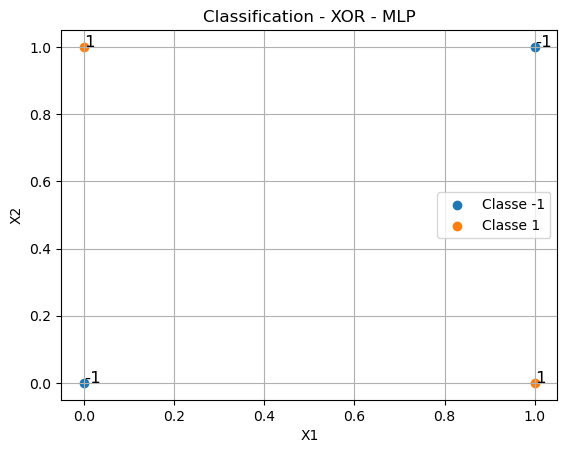

In [5]:
# === Test MLP sur XOR ===
X_xor = np.array([
    [0, 0], [0, 1], [1, 0], [1, 1]
])
Y_xor = np.array([-1, 1, 1, -1])
test_mlp(X_xor, Y_xor, "Classification - XOR")

# === Test MLP sur CROSS ===


--- Classification - Cross (MLP) ---
Exemple 0 : Prédit = 1, Vrai = 1, Sortie MLP = 0.144
Exemple 1 : Prédit = -1, Vrai = 1, Sortie MLP = -0.915
Exemple 2 : Prédit = 1, Vrai = 1, Sortie MLP = 0.113
Exemple 3 : Prédit = 1, Vrai = 1, Sortie MLP = 0.145
Exemple 4 : Prédit = 1, Vrai = 1, Sortie MLP = 0.144
Exemple 5 : Prédit = -1, Vrai = 1, Sortie MLP = -0.039
Exemple 6 : Prédit = 1, Vrai = 1, Sortie MLP = 0.146
Exemple 7 : Prédit = 1, Vrai = 1, Sortie MLP = 0.144
Exemple 8 : Prédit = 1, Vrai = 1, Sortie MLP = 0.145
Exemple 9 : Prédit = 1, Vrai = 1, Sortie MLP = 0.127
Exemple 10 : Prédit = 1, Vrai = 1, Sortie MLP = 0.137
Exemple 11 : Prédit = 1, Vrai = 1, Sortie MLP = 0.133
Exemple 12 : Prédit = -1, Vrai = 1, Sortie MLP = -0.040
Exemple 13 : Prédit = 1, Vrai = 1, Sortie MLP = 0.145
Exemple 14 : Prédit = -1, Vrai = 1, Sortie MLP = -0.041
Exemple 15 : Prédit = 1, Vrai = 1, Sortie MLP = 0.144
Exemple 16 : Prédit = -1, Vrai = 1, Sortie MLP = -0.676
Exemple 17 : Prédit = 1, Vrai = 1, Sortie ML

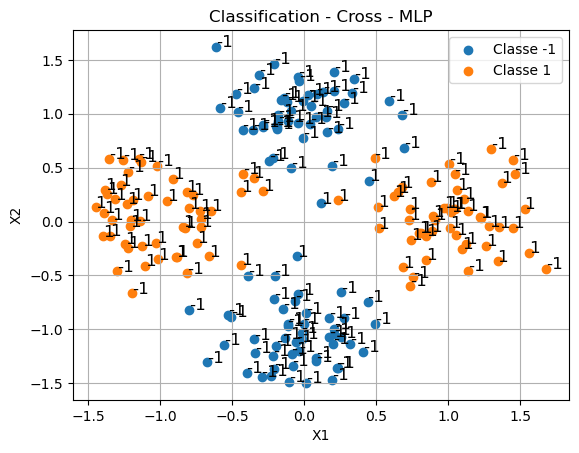

In [ ]:
# === Test MLP sur CROSS ===
np.random.seed(0)
X_cross = np.concatenate([
    np.random.randn(50, 2) * 0.3 + [1, 0],
    np.random.randn(50, 2) * 0.3 + [-1, 0],
    np.random.randn(50, 2) * 0.3 + [0, 1],
    np.random.randn(50, 2) * 0.3 + [0, -1],
])
Y_cross = np.array([1]*100 + [-1]*100)
test_mlp(X_cross, Y_cross, "MLP - Cross")

# === Test MLP sur Multi Linear 3 classes ===


--- MLP - MultiLinear - Classe 0 vs autres (MLP) ---
Exemple 0 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 1 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 2 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 3 : Prédit = 1, Vrai = 1, Sortie MLP = 1.000
Exemple 4 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 5 : Prédit = 1, Vrai = 1, Sortie MLP = 1.000
Exemple 6 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 7 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 8 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 9 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 10 : Prédit = 1, Vrai = 1, Sortie MLP = 1.000
Exemple 11 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 12 : Prédit = 1, Vrai = 1, Sortie MLP = 1.000
Exemple 13 : Prédit = 1, Vrai = 1, Sortie MLP = 1.000
Exemple 14 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 15 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 16 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Ex

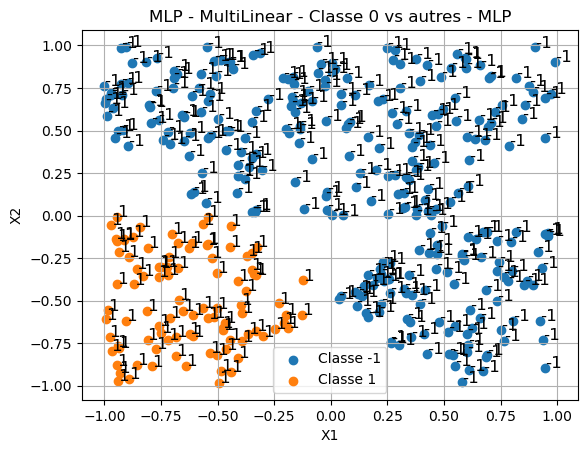

In [9]:
# === Test MLP sur Multi Linear (3 classes) ===
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([
    [1, 0, 0] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else 
    [0, 1, 0] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else 
    [0, 0, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else 
    [0, 0, 0] for p in X
])

X = X[~np.all(Y == [0, 0, 0], axis=1)]
Y = Y[~np.all(Y == [0, 0, 0], axis=1)]
labels = np.argmax(Y, axis=1)  # convert one-hot to class index: 0, 1, 2

# Pour l'instant, entraînement MLP binaire sur classe 0 vs autres (exemple)
Y_binary = np.where(labels == 0, 1, -1)
test_mlp(X, Y_binary, "MLP - MultiLinear - Classe 0 vs autres")

# === Test MLP sur MultiCross ===


--- Modèle MLP - Multicross (MLP) ---
Exemple 0 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 1 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 2 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 3 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 4 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 5 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 6 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 7 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 8 : Prédit = -1, Vrai = -1, Sortie MLP = -1.000
Exemple 9 : Prédit = -1, Vrai = -1, Sortie MLP = -0.977
Exemple 10 : Prédit = -1, Vrai = 1, Sortie MLP = -0.545
Exemple 11 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 12 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 13 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 14 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 15 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exemple 16 : Prédit = -1, Vrai = -1, Sortie MLP = -0.544
Exe

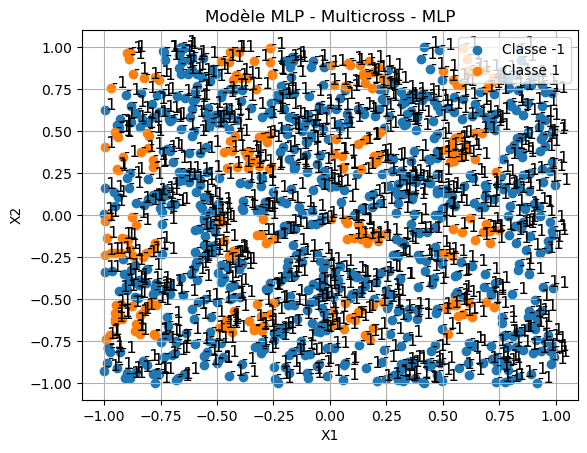

In [10]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([
    [1, 0, 0] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else 
    [0, 1, 0] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else 
    [0, 0, 1] for p in X])

labels = np.argmax(Y, axis=1)
Y_binary_0 = np.where(labels == 0, 1, -1)
test_mlp(X, Y_binary_0, "Modèle MLP - Multicross")
